# 4DVarNet DoubleLSTM - Gap-Fill North Sea SPM Satellite Observations
This can be used to: 

- Test a pre-trained model on 1x1 km SPM observations (CMEMS).  
- Postprocess tested data into a masked netcdf. 
        
**NOTES FOR US AND THINGS i NEED HELP WITH:**
- REPLACING THE CREDENTIALS WITH THE EDITO LINKED CREDENTIALS

injest EDITO secrets.
  
- TESTING THE LIMITS OF THE GPU TO NOT NEED SLICING

Current extent_lon and extent_lat are based on what works for the GPU on the Deltares-cluster.
  
- IMPLEMENTING IT ON THE GPU

The only way to see if this script works right now is to run it on the GPU (see script_daskenv.sh), otherwise you get a CUDA availability error.
  
- SAVING THE TEST OUTPUT(S) ONTO EDITO

Currently working with local p-drive paths. We should change this into EDITO relative paths. Some of these paths are currently hard coded in the function file (saving the data). 

  
- DATA PATHS/NAMES

Depending on your preference, you might want to change some default file names. These are hardcoded into the functions ..  

- CURRENTLY NO SMOOTHENING/BLURRING OF THE OUTPUT.

If we want, Lotta could add it in. 
  
- ONCE THE FINAL OUTPUT IS SAVED, YOU COULD PUT SOMETHING IN THAT CLEANS OUT THE REST OF THE DIRECTORY, AS THOSE ARE INBETWEEN OUTPUTS THAT ARE NO LONGER NEEDED. (ESPECIALLY IF SLICES ARE NECESSARY, THE FOLDER CAN GET QUITE MESSY )
- THE GPU ENVIRONMENT IS CURRENTLY THIS 4DVARNET_TRIAL FOLDER. DEPENDECIES AND THE YAML FILE ARE INCLUDED. i'VE ALSO INCLUDED A SHORT VERSION, WITH THE PACKAGES THAT I THINK ARE THE BARE MINIMUM. BECAUSE OF OUR GPU, I'VE NOT TESTED THIS THO!

#### Import necessary packages, functions and credentials


In [12]:
import testing as ts 
import FunctionFile as ff
import os
import xarray as xr

##%for me, removed later
import numpy as np
import matplotlib.pyplot as plt

username = 'copernicus-user-name'
password = 'copernicus-password'

print('Everything loaded correctly')

Everything loaded correctly


#### Define Spatial and Temporal Domain of Interest


INFO - 2025-09-24T14:15:16Z - Selected dataset version: "202311"
INFO - 2025-09-24T14:15:16Z - Selected dataset part: "default"
WARNING - 2025-09-24T14:15:16Z - The dataset cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D, version '202311', part 'default' is currently being updated. Data after 2003-02-01T00:00:00.000Z may not be up to date.


<xarray.Dataset> Size: 75MB
Dimensions:    (time: 15, latitude: 808, longitude: 1545)
Coordinates:
  * latitude   (latitude) float32 3kB 45.01 45.02 45.03 ... 53.39 53.4 53.41
  * longitude  (longitude) float32 6kB -10.58 -10.57 -10.56 ... 5.495 5.505
  * time       (time) datetime64[ns] 120B 2023-12-03 2023-12-10 ... 2024-03-10
Data variables:
    SPM        (time, latitude, longitude) float32 75MB dask.array<chunksize=(1, 808, 1024), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.8, ACDD-1.3
    contact:      servicedesk.cmems@acri-st.fr
    institution:  ACRI
    comment:      average
    history:      Created using software developed at ACRI-ST
    references:   http://www.globcolour.info GlobColour has been originally f...
    title:        cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D
    source:       surface observation


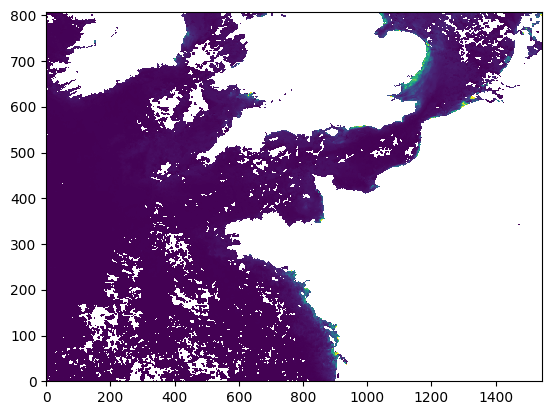

C:\SnapVolumesTemp\MountPoints\{45c63495-0000-0000-0000-100000000000}\{5616dcf8-2785-46cf-bde8-3f208907a931}\SVROOT\Users\beyaard\AppData\Local\miniforge3\envs\jupyter_env\Lib\site-packages\dask\array\reductions.py:291: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(x_chunk, axis=axis, keepdims=keepdims)


In [2]:
#define minimum and maximum spatial domain (in range  lon: -46° to 13° , lat:  20° to 66°)
min_lat, max_lat= 52.9 , 53.42   #minimum and maximum latitude  
min_lon, max_lon= 4.58, 6.51     #minimum and maximum longitude

#FOR ME! WHEN TESTING LARGER DOMAIN THAT NEEDS SLICING  => REMOVE LATER
min_lat, max_lat= 45.0 , 53.42
min_lon, max_lon= -10.58, 5.51   

#define first and last day of timeframe (starting from 1997-10-09)
#and timestep (W=weekly, D=daily). Daily is higher computational costs and lower accuracy 
start_day='2024-01-01'  #yyyy-mm-dd
end_day= '2024-02-01'   #yyyy-mm-dd 
timestep='W' #or 'D', higher computational costs and lower accuracy 

#retrieve cmems satellite data 
data=ff.opencmemsdataset(username, password,start_day, end_day, min_lat, max_lat, min_lon, max_lon, timestep) 

print(data)
plt.pcolormesh(data['SPM'][1])
#the time will automatically be 5 weeks/days earlier and later than what you have given. This is so that the algorithm has enough data at the dates of interest.


#### Normalize the dataset, and prepare a land mask. 
Depending on the spatial extent of the dataset, the notebook will slice large domains into multiple (overlapping) slices, for computational effeciency. 


In [ ]:
#check the spatial extend of the data 
extent_lon=306
extent_lat=406

#normalize the data
if len(data.latitude) > extent_lat or len(data.longitude) > extent_lon:
    print("Warning: Dataset dimensions exceed maximum size, it will be sliced!")
    norm_data=ff.compute_slices(data,extent_lon,extent_lat)

else: 
    norm_data=ff.normalizedata(data)

In [9]:
#generate the land mask 
mask=ff.compute_mask(username, password,start_day, end_day, min_lat, max_lat, min_lon, max_lon, timestep)

INFO - 2025-09-24T14:17:18Z - Selected dataset version: "202311"
INFO - 2025-09-24T14:17:18Z - Selected dataset part: "default"
WARNING - 2025-09-24T14:17:18Z - The dataset cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D, version '202311', part 'default' is currently being updated. Data after 2003-02-01T00:00:00.000Z may not be up to date.


### Gap-fill the data 
REMOVE LATER: FOR US, THIS SECTION CAN ONLY BE RUN ON THE H7 GPU. COMMENT OUT ALL THE OTHER CELLS, RUN THE SameWorkflownow... etc, AND CONTINUE WITH THE SCRIPT... 

In [5]:
#retrieve the nr of slices 
folder_path = r'../../../../05-Models/WP6/4DVarNet/JupyterNotebook/output/'  # ← Replace with edito catalog path or smth?

slicenr = sum(
    1 for entry in os.scandir(folder_path)
    if entry.is_file() and entry.name.startswith('CMEMS_') and entry.name.endswith('.nc')
)
print(f'Gap-filling {slicenr} slice(s)')

Gap-filling 20 slice(s)


In [ ]:
#run these slices through the testing script
## curent only works on a gpu with cuda thingss  
gap_filled=ts.testing_4dvarnet(folder_path,r'../../../../05-Models/WP6/4DVarNet/JupyterNotebook/pre_trained_model.pt',slicenr) 

## Post-Process the filled output into a useable product
- Merging the overlapped slices back together, taking the mean of the overlapping areas.
- Denormalization
- Masking the output. 


<xarray.Dataset> Size: 10MB
Dimensions:    (latitude: 808, longitude: 1545)
Coordinates:
  * latitude   (latitude) float32 3kB 45.01 45.02 45.03 ... 53.39 53.4 53.41
  * longitude  (longitude) float32 6kB -10.58 -10.57 -10.56 ... 5.495 5.505
Data variables:
    flags      (latitude, longitude) float64 10MB ...
Inferred grid shape: 4 rows x 5 cols
<xarray.Dataset> Size: 50MB
Dimensions:  (time: 5, lat: 808, lon: 1545)
Coordinates:
  * time     (time) datetime64[ns] 40B 2024-01-07 2024-01-14 ... 2024-02-04
  * lat      (lat) float32 3kB 45.01 45.02 45.03 45.04 ... 53.39 53.4 53.41
  * lon      (lon) float32 6kB -10.58 -10.57 -10.56 -10.55 ... 5.484 5.495 5.505
Data variables:
    SPM      (time, lat, lon) float64 50MB dask.array<chunksize=(5, 248, 348), meta=np.ndarray>


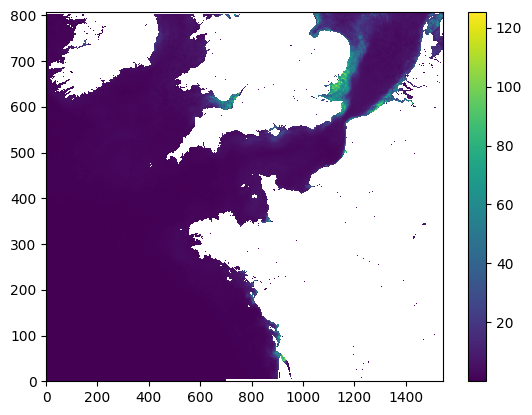

In [17]:
#load the mask 
mask=xr.open_dataset(folder_path+'mask.nc')
print('Mask specifics: 'mask)

#%%merge the data back together 
filled=ff.load_overlap(folder_path,slicenr)
#de-normalize the data 
filled['SPM'] = (10 ** filled['SPM'])*mask['flags'].data

print('Gap-filled specifics: 'filled)

### Visualization of the first time 

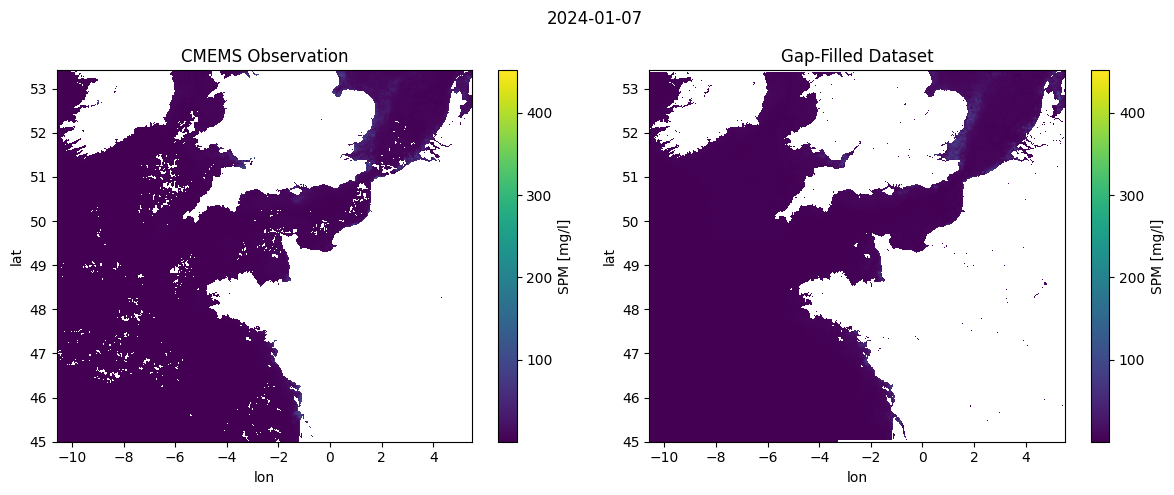

In [34]:

# find cbar limits
vmin = np.nanmin([data['SPM'][0].min(), filled['SPM'][0].min()])
vmax = np.nanmax([data['SPM'][0].max(), filled['SPM'][0].max()])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Left plot: Satellite data
mesh0 = axes[0].pcolormesh(
    data['longitude'],
    data['latitude'],
    data['SPM'][0],
    shading='auto',
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title('CMEMS Observation')
axes[0].set_xlabel('lon')
axes[0].set_ylabel('lat')
fig.colorbar(mesh0, ax=axes[0], label='SPM [mg/l]')

# Right plot: Filled data
mesh1 = axes[1].pcolormesh(
    filled['lon'],
    filled['lat'],
    filled['SPM'][0],
    shading='auto',
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title("Gap-Filled Dataset")
axes[1].set_xlabel('lon')
axes[1].set_ylabel('lat')
fig.colorbar(mesh1, ax=axes[1], label='SPM [mg/l]')
plt.suptitle(str(filled['time'][0].data)[:10])
plt.tight_layout()
plt.show()


## Export file 


In [35]:
filled.to_netcdf(r'p:\11210528-foccus\05-Models\WP6\4DVarNet\JupyterNotebook\output\CMEMS_gapfilled.nc')